
# BMRCL Next-Hour Demand Prediction — Raw Data Validation & EDA

**Project:** Short-term station-level passenger boarding demand prediction for Bengaluru Namma Metro (BMRCL)

**Primary target definition**

\[
D_{s,t+1}=\text{number of passengers boarding station }s\text{ during the next hour}
\]

This notebook is the **data-validation and raw-EDA stage** of the research pipeline. It does not train predictive models.

It is designed to:

1. Audit all raw CSV files and their schemas.
2. Validate the primary station-hourly demand data.
3. Validate weather and calendar coverage.
4. Check the September wide-format ridership file against the canonical station-hourly file.
5. Validate OD/station-pair data and identify derived/leaky fields.
6. Construct a leakage-safe master table for the next-hour forecasting problem.
7. Validate target/lags and the August 19–31 data gap.
8. Generate paper-quality exploratory figures and save them to `figures/`.

> **Important:** The notebook treats information available at time \(t\) as inputs and the demand at \(t+1\) as the target. Observed weather at \(t+1\) is therefore **not** used as a feature.



## Study design decisions used in this notebook

- **Target:** next-hour station boarding demand.
- **Primary target source:** `station-hourly.csv`.
- **Primary modeling period:** from **2025-08-11** onward, because the Yellow Line began passenger service on August 11, 2025.
- The raw station-hourly data contain a **gap from August 19–31, 2025**. The notebook preserves this gap rather than imputing it.
- Lags such as \(t-24\) and \(t-168\) are created by **exact timestamp lookup**, not blind row shifting. This prevents a multi-day gap from being mistaken for a short lag.
- The current-hour observed weather is used as a contextual feature. Future observed weather is not.
- `stationpair-hourly-enhanced.csv` is kept for future spatial/OD experiments, but its `Revenue` field is not used as a predictor because it is derived from ridership.


In [1]:

from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)
pd.set_option("display.width", 140)

print("Python:", __import__("sys").version.split()[0])
print("Pandas:", pd.__version__)
print("NumPy:", np.__version__)


Python: 3.11.0
Pandas: 2.3.3
NumPy: 2.4.6


In [20]:
plt.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman", "DejaVu Serif"],
    "font.size": 10,

    # Axes
    "axes.titlesize": 11,
    "axes.labelsize": 10,
    "axes.labelcolor": "black",
    "axes.edgecolor": "black",
    "axes.linewidth": 0.8,

    # Ticks
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "xtick.color": "black",
    "ytick.color": "black",

    # Lines
    "lines.linewidth": 1.3,

    # Legend
    "legend.fontsize": 9,
    "legend.frameon": False,

    # Figure
    "figure.facecolor": "white",
    "axes.facecolor": "white",
})

In [2]:

# Resolve the Data/ directory.
# When the notebook is placed in the repository root, Path("Data") should be used.
# The fallback path below is only for reproducing the analysis in the current environment.

candidates = [
    Path("Data"),
    Path("../Data"),
    Path("/mnt/data/BMRCL_Data/Data"),
]

DATA_DIR = next((p for p in candidates if p.exists() and p.is_dir()), None)

if DATA_DIR is None:
    raise FileNotFoundError(
        "Could not find the Data directory. Place this notebook in the repository root "
        "or set DATA_DIR manually."
    )

PROJECT_ROOT = DATA_DIR.parent
FIGURES_DIR = PROJECT_ROOT / "figures"
OUTPUT_DIR = PROJECT_ROOT / "outputs"
PROCESSED_DIR = PROJECT_ROOT / "processed"

FIGURES_DIR.mkdir(parents=True, exist_ok=True)
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR:", DATA_DIR.resolve())
print("FIGURES_DIR:", FIGURES_DIR.resolve())
print("OUTPUT_DIR:", OUTPUT_DIR.resolve())
print("PROCESSED_DIR:", PROCESSED_DIR.resolve())


DATA_DIR: D:\New Downloads\BMRCL_Demand\Data
FIGURES_DIR: D:\New Downloads\BMRCL_Demand\figures
OUTPUT_DIR: D:\New Downloads\BMRCL_Demand\outputs
PROCESSED_DIR: D:\New Downloads\BMRCL_Demand\processed


## 1. Raw-file inventory

In [3]:

# Files expected after the raw-data cleanup.
expected_files = [
    "station-hourly.csv",
    "station-hourly-exits.csv",
    "Bengaluru_AUG-SEPT_Weather.csv",
    "bengaluru_calendar_aug_sep_2025.csv",
    "stationpair-hourly-enhanced.csv",
    "metro_station_parking_details.csv",
    "namma_metro_timings.csv",
    "NammaMetro_Ridership_Dataset.csv",
    "station-codes.csv",
    "station-names.csv",
]

redundant_or_legacy = [
    "BMRCL_September_Hourly_Ridership.csv",
    "stationpair-hourly.csv",
    "august_weather_data_2025.csv",
]

manifest = []
for name in expected_files + redundant_or_legacy:
    p = DATA_DIR / name
    manifest.append({
        "file": name,
        "exists": p.exists(),
        "size_MB": round(p.stat().st_size / (1024**2), 3) if p.exists() else np.nan,
        "status": "active" if name in expected_files else "archive/remove",
    })

manifest_df = pd.DataFrame(manifest)
display(manifest_df)

missing_active = manifest_df[(manifest_df["status"] == "active") & (~manifest_df["exists"])]
if len(missing_active):
    print("WARNING: Missing active files:")
    display(missing_active)
else:
    print("All active files are present.")


,file,exists,size_MB,status
0,station-hourly.csv,True,3.023,active
1,station-hourly-exits.csv,True,3.126,active
2,Bengaluru_AUG-SEPT_Weather.csv,True,1.297,active
3,bengaluru_calendar_aug_sep_2025.csv,True,0.009,active
4,stationpair-hourly-enhanced.csv,True,76.175,active
5,metro_station_parking_details.csv,True,0.002,active
6,namma_metro_timings.csv,True,0.012,active
7,NammaMetro_Ridership_Dataset.csv,True,0.035,active
8,station-codes.csv,True,0.002,active
9,station-names.csv,True,0.001,active


All active files are present.



## 2. Load the raw datasets

The BMRCL files downloaded from the RTI-derived source use a semicolon (`;`) delimiter. The newer weather, calendar, and September wide-format files use commas.


In [4]:

def read_csv(name, sep=",", **kwargs):
    path = DATA_DIR / name
    if not path.exists():
        raise FileNotFoundError(path)
    return pd.read_csv(path, sep=sep, **kwargs)

station_hourly = read_csv(
    "station-hourly.csv",
    sep=";",
    dtype={"Hour": "int16", "Ridership": "int64"},
)
station_exits = read_csv(
    "station-hourly-exits.csv",
    sep=";",
    dtype={"Hour": "int16", "Ridership": "int64"},
)
weather = read_csv("Bengaluru_AUG-SEPT_Weather.csv")
calendar = read_csv("bengaluru_calendar_aug_sep_2025.csv")
stationpair = read_csv("stationpair-hourly-enhanced.csv", sep=";")
parking = read_csv("metro_station_parking_details.csv")
timings = read_csv("namma_metro_timings.csv")
system_ridership = read_csv("NammaMetro_Ridership_Dataset.csv")
station_codes = read_csv("station-codes.csv", sep=";")
station_names = read_csv("station-names.csv", sep=";")

# Redundant September wide-format file is loaded only for equivalence validation.
sept_wide = read_csv("BMRCL_September_Hourly_Ridership.csv")

datasets = {
    "station_hourly": station_hourly,
    "station_exits": station_exits,
    "weather": weather,
    "calendar": calendar,
    "stationpair_enhanced": stationpair,
    "parking": parking,
    "timings": timings,
    "system_ridership": system_ridership,
    "station_codes": station_codes,
    "station_names": station_names,
    "sept_wide": sept_wide,
}

summary = pd.DataFrame([
    {
        "dataset": name,
        "rows": df.shape[0],
        "columns": df.shape[1],
        "missing_cells": int(df.isna().sum().sum()),
        "duplicate_rows": int(df.duplicated().sum()),
    }
    for name, df in datasets.items()
])

display(summary)


,dataset,rows,columns,missing_cells,duplicate_rows
0,station_hourly,92280,4,0,0
1,station_exits,95616,4,0,0
2,weather,8651,20,276,0
3,calendar,61,15,158,0
4,stationpair_enhanced,1273629,9,0,0
5,parking,77,6,0,0
6,timings,224,8,214,0
7,system_ridership,460,14,0,0
8,station_codes,95,2,0,0
9,station_names,22,2,0,0


## 3. Schema and basic quality audit

In [5]:

schema_rows = []

for name, df in datasets.items():
    for col in df.columns:
        schema_rows.append({
            "dataset": name,
            "column": col,
            "dtype": str(df[col].dtype),
            "nulls": int(df[col].isna().sum()),
            "n_unique": int(df[col].nunique(dropna=True)),
        })

schema_df = pd.DataFrame(schema_rows)
display(schema_df)


,dataset,column,dtype,nulls,n_unique
0,station_hourly,Date,object,0,48
1,station_hourly,Hour,int16,0,24
2,station_hourly,Station,object,0,83
3,station_hourly,Ridership,int64,0,2957
4,station_exits,Date,object,0,48
...,...,...,...,...,...
107,sept_wide,H20,int64,0,993
108,sept_wide,H21,int64,0,739
109,sept_wide,H22,int64,0,513
110,sept_wide,H23,int64,0,162


### Core station-hourly validation

In [6]:

def check(condition, message):
    status = "PASS" if bool(condition) else "FAIL"
    print(f"[{status}] {message}")
    return bool(condition)

# Parse dates.
station_hourly["Date"] = pd.to_datetime(station_hourly["Date"], errors="coerce")
station_exits["Date"] = pd.to_datetime(station_exits["Date"], errors="coerce")

check(station_hourly["Date"].notna().all(), "Primary demand dates parse successfully.")
check(station_hourly["Hour"].between(0, 23).all(), "Primary demand hour values are in 0..23.")
check(station_hourly["Ridership"].notna().all(), "Primary demand has no null ridership values.")
check((station_hourly["Ridership"] >= 0).all(), "Primary demand has no negative values.")
check(
    station_hourly.duplicated(["Date", "Hour", "Station"]).sum() == 0,
    "No duplicate station-hour observations in station-hourly.csv."
)

station_dates = station_hourly["Date"].nunique()
station_count = station_hourly["Station"].nunique()

print(f"Observed dates in primary dataset: {station_dates}")
print(f"Unique stations in primary dataset: {station_count}")
print(f"Date range: {station_hourly['Date'].min().date()} to {station_hourly['Date'].max().date()}")
print(f"Zero-demand share: {(station_hourly['Ridership'] == 0).mean():.2%}")


[PASS] Primary demand dates parse successfully.
[PASS] Primary demand hour values are in 0..23.
[PASS] Primary demand has no null ridership values.
[PASS] Primary demand has no negative values.
[PASS] No duplicate station-hour observations in station-hourly.csv.
Observed dates in primary dataset: 48
Unique stations in primary dataset: 83
Date range: 2025-08-01 to 2025-09-30
Zero-demand share: 19.72%


In [7]:

# Station-day completeness.
station_day_counts = (
    station_hourly.groupby(["Date", "Station"])
    .size()
    .rename("hours_observed")
    .reset_index()
)

check(
    (station_day_counts["hours_observed"] == 24).all(),
    "Every observed station-day contains exactly 24 hourly observations."
)

# Expected availability matrix over all dates in the file.
all_calendar_dates = pd.date_range(
    station_hourly["Date"].min(),
    station_hourly["Date"].max(),
    freq="D"
)
all_stations = sorted(station_hourly["Station"].unique())

expected_pairs = pd.MultiIndex.from_product(
    [all_calendar_dates, all_stations],
    names=["Date", "Station"]
)
observed_pairs = pd.MultiIndex.from_frame(
    station_hourly[["Date", "Station"]].drop_duplicates()
)
missing_station_days = expected_pairs.difference(observed_pairs).to_frame(index=False)

print(f"Missing station-day combinations across full Aug-Sep range: {len(missing_station_days):,}")

if not missing_station_days.empty:
    missing_by_date = missing_station_days.groupby("Date").size().rename("missing_stations")
    display(missing_by_date.to_frame())

# Highlight the August 19-31 gap explicitly.
gap_dates = pd.date_range("2025-08-19", "2025-08-31", freq="D")
gap_present = station_hourly[station_hourly["Date"].isin(gap_dates)].shape[0]
print(f"Rows observed during Aug 19-31 gap: {gap_present:,}")


[PASS] Every observed station-day contains exactly 24 hourly observations.
Missing station-day combinations across full Aug-Sep range: 1,218


,missing_stations
Date,
2025-08-01,15
2025-08-02,15
2025-08-03,14
2025-08-04,15
2025-08-05,15
2025-08-06,13
2025-08-07,14
2025-08-08,13
2025-08-09,11


Rows observed during Aug 19-31 gap: 0


### Yellow Line / early-August station availability

In [8]:

availability_by_date = (
    station_hourly.groupby("Date")["Station"]
    .nunique()
    .rename("stations_observed")
    .reset_index()
)

display(
    availability_by_date[
        availability_by_date["Date"].between("2025-08-01", "2025-08-18")
    ]
)

print(
    "Interpretation: the primary station-hourly dataset contains fewer than 83 stations "
    "before Aug 11, then reaches the full 83-station network from Aug 11 onward."
)


,Date,stations_observed
0,2025-08-01,68
1,2025-08-02,68
2,2025-08-03,69
3,2025-08-04,68
4,2025-08-05,68
5,2025-08-06,70
6,2025-08-07,69
7,2025-08-08,70
8,2025-08-09,72
9,2025-08-10,69


Interpretation: the primary station-hourly dataset contains fewer than 83 stations before Aug 11, then reaches the full 83-station network from Aug 11 onward.


### Exit-demand validation

In [9]:

check(station_exits["Date"].notna().all(), "Exit dates parse successfully.")
check(station_exits["Hour"].between(0, 23).all(), "Exit hour values are in 0..23.")
check(station_exits["Ridership"].notna().all(), "Exit demand has no null values.")
check((station_exits["Ridership"] >= 0).all(), "Exit demand has no negative values.")
check(
    station_exits.duplicated(["Date", "Hour", "Station"]).sum() == 0,
    "No duplicate station-hour observations in station-hourly-exits.csv."
)

exit_station_day_counts = station_exits.groupby(["Date", "Station"]).size()
check(
    (exit_station_day_counts == 24).all(),
    "Every observed exit station-day contains exactly 24 hourly observations."
)
print(f"Exit dataset station count: {station_exits['Station'].nunique()}")


[PASS] Exit dates parse successfully.
[PASS] Exit hour values are in 0..23.
[PASS] Exit demand has no null values.
[PASS] Exit demand has no negative values.
[PASS] No duplicate station-hour observations in station-hourly-exits.csv.
[PASS] Every observed exit station-day contains exactly 24 hourly observations.
Exit dataset station count: 83


### Weather validation

In [10]:

weather["datetime"] = pd.to_datetime(
    dict(
        year=weather["year"],
        month=weather["month"],
        day=weather["day"],
        hour=weather["hour"],
    ),
    errors="coerce",
)

check(weather["datetime"].notna().all(), "Weather timestamps parse successfully.")
check(weather.duplicated(["datetime"]).sum() == 0, "No duplicate weather timestamps.")

weather_ranges = pd.DataFrame({
    "feature": ["temp", "rhum", "prcp", "wspd", "pres", "cldc", "coco"],
    "min": [weather[c].min() for c in ["temp", "rhum", "prcp", "wspd", "pres", "cldc", "coco"]],
    "max": [weather[c].max() for c in ["temp", "rhum", "prcp", "wspd", "pres", "cldc", "coco"]],
    "nulls": [weather[c].isna().sum() for c in ["temp", "rhum", "prcp", "wspd", "pres", "cldc", "coco"]],
})
display(weather_ranges)

check((weather["rhum"].dropna().between(0, 100)).all(), "Relative humidity stays within 0..100.")
check((weather["prcp"].dropna() >= 0).all(), "Precipitation is non-negative.")
check((weather["wspd"].dropna() >= 0).all(), "Wind speed is non-negative.")


[PASS] Weather timestamps parse successfully.
[PASS] No duplicate weather timestamps.


,feature,min,max,nulls
0,temp,12.7,35.2,0
1,rhum,10.0,100.0,0
2,prcp,0.0,13.1,55
3,wspd,0.0,37.4,0
4,pres,1001.4,1049.6,27
5,cldc,0.0,8.0,0
6,coco,1.0,18.0,55


[PASS] Relative humidity stays within 0..100.
[PASS] Precipitation is non-negative.
[PASS] Wind speed is non-negative.


True

### Calendar validation

In [11]:

calendar["date"] = pd.to_datetime(calendar["date"], errors="coerce")

check(calendar["date"].notna().all(), "Calendar dates parse successfully.")
check(calendar["date"].duplicated().sum() == 0, "Calendar contains one row per date.")
check(calendar["is_weekend"].isin([0, 1]).all(), "is_weekend is binary.")
check(calendar["is_public_holiday"].isin([0, 1]).all(), "is_public_holiday is binary.")
check(calendar["is_major_city_event"].isin([0, 1]).all(), "is_major_city_event is binary.")
check(calendar["is_working_day_proxy"].isin([0, 1]).all(), "is_working_day_proxy is binary.")

print(
    "Calendar coverage:",
    calendar["date"].min().date(),
    "to",
    calendar["date"].max().date(),
    f"({calendar['date'].nunique()} dates)"
)
display(
    calendar.loc[
        (calendar["is_public_holiday"] == 1) | (calendar["is_major_city_event"] == 1),
        ["date", "day_of_week", "public_holiday", "major_city_event",
         "is_working_day_proxy", "is_day_before_public_holiday", "is_day_after_public_holiday"]
    ]
)


[PASS] Calendar dates parse successfully.
[PASS] Calendar contains one row per date.
[PASS] is_weekend is binary.
[PASS] is_public_holiday is binary.
[PASS] is_major_city_event is binary.
[PASS] is_working_day_proxy is binary.
Calendar coverage: 2025-08-01 to 2025-09-30 (61 dates)


,date,day_of_week,public_holiday,major_city_event,is_working_day_proxy,is_day_before_public_holiday,is_day_after_public_holiday
14,2025-08-15,Friday,Independence Day,NaN,0,0,0
26,2025-08-27,Wednesday,Varasiddhi Vinayaka Vrata (Ganesh Chaturthi),Bengaluru Ganesh Utsava (Basavanagudi),0,0,0
27,2025-08-28,Thursday,NaN,Bengaluru Ganesh Utsava (Basavanagudi),1,0,1
28,2025-08-29,Friday,NaN,Bengaluru Ganesh Utsava (Basavanagudi),1,0,0
29,2025-08-30,Saturday,NaN,Bengaluru Ganesh Utsava (Basavanagudi),0,0,0
30,2025-08-31,Sunday,NaN,Bengaluru Ganesh Utsava (Basavanagudi),0,0,0
31,2025-09-01,Monday,NaN,Bengaluru Ganesh Utsava (Basavanagudi),1,0,0
32,2025-09-02,Tuesday,NaN,Bengaluru Ganesh Utsava (Basavanagudi),1,0,0
33,2025-09-03,Wednesday,NaN,Bengaluru Ganesh Utsava (Basavanagudi),1,0,0
34,2025-09-04,Thursday,NaN,Bengaluru Ganesh Utsava (Basavanagudi),1,1,0


### Station lookup, parking, timetable and system-ridership checks

In [12]:

# Station code mapping
check(station_codes["code"].notna().all() and station_codes["name"].notna().all(),
      "Station-code lookup has no null code/name values.")
multi_codes = (
    station_codes.groupby("name")["code"]
    .nunique()
    .sort_values(ascending=False)
)
print("Stations with multiple station codes:")
display(multi_codes[multi_codes > 1].to_frame("number_of_codes"))

# Station-name alias mapping
check(
    station_names["alt_name"].duplicated().sum() == 0,
    "Station-name aliases are unique."
)

# Parking coverage
print(f"Parking records: {len(parking)}")
print(f"Unique parking station labels: {parking['NAME_OF_STATIONS'].nunique()}")

# Timings
numeric_frequency = pd.to_numeric(
    timings["frequency"].astype(str).str.extract(r"(\\d+(?:\\.\\d+)?)", expand=False),
    errors="coerce"
)
print(f"Timetable rows with numeric frequency: {numeric_frequency.notna().sum()} / {len(timings)}")

# System-level daily ridership
system_ridership["Record Date"] = pd.to_datetime(
    system_ridership["Record Date"], errors="coerce", dayfirst=True
)
check(system_ridership["Record Date"].notna().all(), "System ridership dates parse successfully.")
check(
    system_ridership["Record Date"].duplicated().sum() == 0,
    "System-level ridership has no duplicate dates."
)


[PASS] Station-code lookup has no null code/name values.
Stations with multiple station codes:


,number_of_codes
name,
Challaghatta,3
Banashankari,2
Chickpete,2
Pattanagere,2
Rashtreeya Vidyalaya Road,2
Vijayanagar,2
Mahatma Gandhi Road,2
Krishnarajapura,2
Lalbagh,2


[PASS] Station-name aliases are unique.
Parking records: 77
Unique parking station labels: 77
Timetable rows with numeric frequency: 0 / 224
[PASS] System ridership dates parse successfully.
[PASS] System-level ridership has no duplicate dates.


True

## 4. Validate the September wide-format ridership file

In [13]:

# The September-wide file is expected to be equivalent to the September part of
# station-hourly.csv after reshaping and station-name normalization.

alias_map = dict(zip(station_names["alt_name"], station_names["name"]))

sept_wide["BUSINESS DATE"] = pd.to_datetime(
    sept_wide["BUSINESS DATE"], errors="coerce", dayfirst=True
)
sept_wide["station"] = (
    sept_wide["STATION"]
    .astype(str)
    .str.replace(r"^\d+-", "", regex=True)
    .str.strip()
    .replace(alias_map)
)

hour_cols = [f"H{i:02d}" for i in range(24)]

sept_long = sept_wide.melt(
    id_vars=["BUSINESS DATE", "station"],
    value_vars=hour_cols,
    var_name="hour_label",
    value_name="ridership_wide",
)
sept_long["Hour"] = sept_long["hour_label"].str[1:].astype(int)
sept_long = sept_long.rename(columns={"BUSINESS DATE": "Date"})[
    ["Date", "Hour", "station", "ridership_wide"]
]

sept_canonical = station_hourly[
    station_hourly["Date"].dt.month == 9
].rename(columns={"Station": "station"})[
    ["Date", "Hour", "station", "Ridership"]
]

sept_compare = sept_canonical.merge(
    sept_long,
    on=["Date", "Hour", "station"],
    how="outer",
    indicator=True,
)

both = sept_compare[sept_compare["_merge"] == "both"]

print("September join status:")
display(sept_compare["_merge"].value_counts().rename_axis("_merge").to_frame("rows"))

check(
    len(sept_compare[sept_compare["_merge"] != "both"]) == 0,
    "All September station-hour rows match after reshaping and station-name normalization."
)

check(
    (both["Ridership"] == both["ridership_wide"]).all(),
    "September wide-format ridership exactly matches station-hourly.csv."
)


September join status:


,rows
_merge,
both,59760
left_only,0
right_only,0


[PASS] All September station-hour rows match after reshaping and station-name normalization.
[PASS] September wide-format ridership exactly matches station-hourly.csv.


True

## 5. Validate the enhanced OD/station-pair dataset

In [14]:

od_key = ["Date", "Hour", "Origin Station", "Destination Station"]

stationpair["Date"] = pd.to_datetime(stationpair["Date"], errors="coerce")

check(stationpair["Date"].notna().all(), "OD dates parse successfully.")
check(stationpair["Hour"].between(0, 23).all(), "OD hour values are in 0..23.")
check((stationpair["Ridership"] >= 0).all(), "OD ridership has no negative values.")
check(
    stationpair.duplicated(od_key).sum() == 0,
    "OD observations are unique at Date + Hour + Origin + Destination."
)
check(
    (stationpair["Travelled Stations"] >= 0).all(),
    "Travelled Stations is non-negative."
)
check(
    (stationpair["Revenue"] == stationpair["Ridership"] * stationpair["Fare"]).all(),
    "Revenue is exactly Ridership × Fare (derived field; do not use as an input feature)."
)

print(
    f"OD coverage: {stationpair['Date'].min().date()} to "
    f"{stationpair['Date'].max().date()} ({stationpair['Date'].nunique()} dates)"
)

# Self-origin/self-destination flows are recorded in the source and are retained for
# source-level validation, but should be considered carefully in future OD analyses.
self_flow = stationpair["Origin Station"].eq(stationpair["Destination Station"])
print(f"Self-origin/self-destination OD rows: {self_flow.sum():,}")
print(f"Self-origin/self-destination ridership: {stationpair.loc[self_flow, 'Ridership'].sum():,}")


[PASS] OD dates parse successfully.
[PASS] OD hour values are in 0..23.
[PASS] OD ridership has no negative values.
[PASS] OD observations are unique at Date + Hour + Origin + Destination.
[PASS] Travelled Stations is non-negative.
[PASS] Revenue is exactly Ridership × Fare (derived field; do not use as an input feature).
OD coverage: 2025-08-01 to 2025-08-18 (18 dates)
Self-origin/self-destination OD rows: 15,261
Self-origin/self-destination ridership: 48,280



## 6. Define the forecasting study window

The primary model will begin on **2025-08-11** so that all 83 stations are in the operational dataset.

The Aug 19–31 gap is left as a real gap. It is **not imputed**.


In [15]:

START_DATE = pd.Timestamp("2025-08-11")
END_DATE = pd.Timestamp("2025-09-30")

demand = station_hourly.copy()
demand["datetime"] = demand["Date"] + pd.to_timedelta(demand["Hour"], unit="h")
demand = demand.sort_values(["Station", "datetime"]).reset_index(drop=True)

study = demand[
    demand["datetime"].between(START_DATE, END_DATE + pd.Timedelta(hours=23))
].copy()

print("Study rows:", f"{len(study):,}")
print("Study stations:", study["Station"].nunique())
print("Study datetime range:", study["datetime"].min(), "to", study["datetime"].max())
print("Study dates present:", study["Date"].nunique())

# Expected rows if all 83 stations had all 24 hours for every observed study date:
observed_dates = study["Date"].drop_duplicates().sort_values()
expected_rows_if_full = len(observed_dates) * study["Station"].nunique() * 24
print("Expected rows across observed study dates if complete:", f"{expected_rows_if_full:,}")
print("Observed:", f"{len(study):,}")


Study rows: 75,696
Study stations: 83
Study datetime range: 2025-08-11 00:00:00 to 2025-09-30 23:00:00
Study dates present: 38
Expected rows across observed study dates if complete: 75,696
Observed: 75,696


## 7. Build a leakage-safe next-hour forecasting table

In [16]:

# Start from the current-hour station demand table.
master = study[["datetime", "Date", "Hour", "Station", "Ridership"]].copy()
master = master.rename(columns={"Ridership": "demand"})

# Merge current-hour weather only.
weather_cols = ["datetime", "temp", "rhum", "prcp", "wspd", "pres", "cldc", "coco"]
weather_model = weather[weather_cols].copy()

master = master.merge(
    weather_model,
    on="datetime",
    how="left",
    validate="many_to_one",
)

# Merge date-known calendar/context features.
calendar_model = calendar[
    [
        "date",
        "day_of_week",
        "is_weekend",
        "is_public_holiday",
        "is_major_city_event",
        "is_working_day_proxy",
        "is_day_before_public_holiday",
        "is_day_after_public_holiday",
    ]
].rename(columns={"date": "Date"})

master = master.merge(
    calendar_model,
    on="Date",
    how="left",
    validate="many_to_one",
)

# Sort for reproducibility.
master = master.sort_values(["Station", "datetime"]).reset_index(drop=True)

# Helper: exact timestamp lookup within station.
demand_lookup = (
    study[["Station", "datetime", "Ridership"]]
    .rename(columns={"Ridership": "_lookup_demand"})
)

def add_exact_lag(df, lag_hours):
    # For a row at time t, look up demand at exactly t-lag_hours.
    lookup = demand_lookup.copy()
    lookup["datetime"] = lookup["datetime"] + pd.Timedelta(hours=lag_hours)
    lookup = lookup.rename(columns={"_lookup_demand": f"demand_lag_{lag_hours}h"})
    return df.merge(
        lookup,
        on=["Station", "datetime"],
        how="left",
        validate="one_to_one",
    )

# Create safe historical lags. The lookup time is t-lag.
for lag in [1, 2, 3, 24, 168]:
    master = add_exact_lag(master, lag)

# Create target using exact +1 hour lookup.
target_lookup = demand_lookup.copy()
target_lookup["datetime"] = target_lookup["datetime"] - pd.Timedelta(hours=1)
target_lookup = target_lookup.rename(columns={"_lookup_demand": "target_next_hour"})

master = master.merge(
    target_lookup,
    on=["Station", "datetime"],
    how="left",
    validate="one_to_one",
)

# Time-based rolling features over available history.
# The window is timestamp-based so the Aug 19–31 gap does not become fake "adjacent" rows.
roll_base = (
    master[["Station", "datetime", "demand"]]
    .sort_values(["Station", "datetime"])
    .set_index("datetime")
)

for window, label in [("3h", "rolling_mean_3h"), ("6h", "rolling_mean_6h"), ("24h", "rolling_mean_24h")]:
    rolled = (
        roll_base.groupby("Station")["demand"]
        .rolling(window, closed="both")
        .mean()
        .rename(label)
        .reset_index()
    )
    master = master.merge(
        rolled,
        on=["Station", "datetime"],
        how="left",
        validate="one_to_one",
    )

# Add simple deterministic time representations.
master["day_of_week_num"] = master["datetime"].dt.dayofweek
master["month_num"] = master["datetime"].dt.month
master["hour_sin"] = np.sin(2 * np.pi * master["Hour"] / 24)
master["hour_cos"] = np.cos(2 * np.pi * master["Hour"] / 24)

master.head()


,datetime,Date,Hour,Station,demand,temp,rhum,prcp,wspd,pres,cldc,coco,day_of_week,is_weekend,is_public_holiday,is_major_city_event,is_working_day_proxy,is_day_before_public_holiday,is_day_after_public_holiday,demand_lag_1h,demand_lag_2h,demand_lag_3h,demand_lag_24h,demand_lag_168h,target_next_hour,rolling_mean_3h,rolling_mean_6h,rolling_mean_24h,day_of_week_num,month_num,hour_sin,hour_cos
0,2025-08-11 00:00:00,2025-08-11,0,Attiguppe,0,20.0,98,0.1,3.6,1011.6,7,7.0,Monday,0,0,0,1,0,0,NaN,NaN,NaN,NaN,NaN,0.0,0.00,0.0,0.0,0,8,0.000000,1.000000
1,2025-08-11 01:00:00,2025-08-11,1,Attiguppe,0,19.3,98,0.2,14.0,1012.1,8,7.0,Monday,0,0,0,1,0,0,0.0,NaN,NaN,NaN,NaN,0.0,0.00,0.0,0.0,0,8,0.258819,0.965926
2,2025-08-11 02:00:00,2025-08-11,2,Attiguppe,0,19.6,97,0.9,14.4,1013.1,8,8.0,Monday,0,0,0,1,0,0,0.0,0.0,NaN,NaN,NaN,0.0,0.00,0.0,0.0,0,8,0.500000,0.866025
3,2025-08-11 03:00:00,2025-08-11,3,Attiguppe,0,20.2,96,0.5,3.6,1013.6,7,8.0,Monday,0,0,0,1,0,0,0.0,0.0,0.0,NaN,NaN,5.0,0.00,0.0,0.0,0,8,0.707107,0.707107
4,2025-08-11 04:00:00,2025-08-11,4,Attiguppe,5,22.0,84,0.0,16.9,1013.4,8,3.0,Monday,0,0,0,1,0,0,0.0,0.0,0.0,NaN,NaN,85.0,1.25,1.0,1.0,0,8,0.866025,0.500000


## 8. Validate the master forecasting table and check for leakage

In [17]:

feature_cols_context = [
    "Station", "Hour", "day_of_week_num", "month_num",
    "hour_sin", "hour_cos",
    "is_weekend", "is_public_holiday", "is_major_city_event",
    "is_working_day_proxy", "is_day_before_public_holiday",
    "is_day_after_public_holiday",
    "temp", "rhum", "prcp", "wspd", "pres", "cldc", "coco",
]

lag_cols = [
    "demand_lag_1h",
    "demand_lag_2h",
    "demand_lag_3h",
    "demand_lag_24h",
    "demand_lag_168h",
    "rolling_mean_3h",
    "rolling_mean_6h",
    "rolling_mean_24h",
]

target_col = "target_next_hour"

print("Master shape:", master.shape)

check(
    master.duplicated(["Station", "datetime"]).sum() == 0,
    "Master table has no duplicate station-datetime rows."
)
check(
    master["target_next_hour"].isna().sum() > 0,
    "Some target rows are missing only because the next hour is outside the observed data/gap."
)
check(
    (master["target_next_hour"].dropna() >= 0).all(),
    "Observed next-hour target values are non-negative."
)

# Current-hour weather should align exactly with the prediction timestamp.
check(
    master.loc[master["temp"].notna(), "datetime"].notna().all(),
    "Current-hour weather observations map to valid timestamps."
)

# Explicitly document future-looking columns.
future_looking_names = [
    c for c in master.columns
    if any(token in c.lower() for token in ["target", "future", "next"])
]
print("Columns containing explicit future/target labels:", future_looking_names)

check(
    set(future_looking_names).issubset({target_col}),
    "No feature column is explicitly named as a future/next-hour variable."
)

# Sanity check lag columns.
lag_summary = pd.DataFrame({
    "feature": lag_cols,
    "non_null": [master[c].notna().sum() for c in lag_cols],
    "null": [master[c].isna().sum() for c in lag_cols],
    "coverage_pct": [100 * master[c].notna().mean() for c in lag_cols],
})
display(lag_summary)

# Critical gap-specific validation: Sep 1 has no Aug 31 observation, so lag_24 must be missing.
sep1 = master[master["Date"] == pd.Timestamp("2025-09-01")]
print("Sep 1 lag_24 coverage:", sep1["demand_lag_24h"].notna().mean())
check(
    sep1["demand_lag_24h"].isna().all(),
    "Sep 1 lag_24 is missing because Aug 31 is outside the observed station-hourly dataset."
)

# Similar check for Sep 1 lag_168: the exact previous-week observations in Aug 25 are also unavailable.
check(
    sep1["demand_lag_168h"].isna().all(),
    "Sep 1 lag_168 is missing because the exact Aug 25 timestamps are not observed."
)

# Final training table candidate: rows where target exists.
training_ready = master.dropna(subset=[target_col]).copy()
print(f"Rows with an observed next-hour target: {len(training_ready):,}")


# Stronger leakage audit: independently reconstruct target/lags from the raw demand table.
raw_lookup = study[["Station", "datetime", "Ridership"]].copy()

# Validate the next-hour target.
target_check = master[["Station", "datetime", "target_next_hour"]].dropna().copy()
target_expected = raw_lookup.rename(columns={"datetime": "target_datetime", "Ridership": "expected_target"})
target_expected["target_datetime"] = target_expected["target_datetime"] - pd.Timedelta(hours=1)
target_check = target_check.merge(
    target_expected,
    left_on=["Station", "datetime"],
    right_on=["Station", "target_datetime"],
    how="left",
)
check(
    (target_check["target_next_hour"] == target_check["expected_target"]).all(),
    "Every non-null target_next_hour exactly equals demand at the next observed hour."
)

# Validate each lag independently.
for lag in [1, 2, 3, 24, 168]:
    col = f"demand_lag_{lag}h"
    lag_expected = raw_lookup.rename(columns={"datetime": "lookup_datetime", "Ridership": "expected"})
    lag_expected["lookup_datetime"] = lag_expected["lookup_datetime"] + pd.Timedelta(hours=lag)
    lag_check = master[["Station", "datetime", col]].dropna().merge(
        lag_expected,
        left_on=["Station", "datetime"],
        right_on=["Station", "lookup_datetime"],
        how="left",
    )
    check(
        (lag_check[col] == lag_check["expected"]).all(),
        f"{col} exactly matches demand at t-{lag} hours wherever the historical value exists."
    )

# The weather features are intentionally current-hour values.
print("Weather feature timestamps are the same timestamps as the forecasting row; observed t+1 weather is not merged.")


Master shape: (75696, 32)
[PASS] Master table has no duplicate station-datetime rows.
[PASS] Some target rows are missing only because the next hour is outside the observed data/gap.
[PASS] Observed next-hour target values are non-negative.
[PASS] Current-hour weather observations map to valid timestamps.
Columns containing explicit future/target labels: ['target_next_hour']
[PASS] No feature column is explicitly named as a future/next-hour variable.


,feature,non_null,null,coverage_pct
0,demand_lag_1h,75530,166,99.780702
1,demand_lag_2h,75364,332,99.561404
2,demand_lag_3h,75198,498,99.342105
3,demand_lag_24h,71712,3984,94.736842
4,demand_lag_168h,47808,27888,63.157895
5,rolling_mean_3h,75696,0,100.000000
6,rolling_mean_6h,75696,0,100.000000
7,rolling_mean_24h,75696,0,100.000000


Sep 1 lag_24 coverage: 0.0
[PASS] Sep 1 lag_24 is missing because Aug 31 is outside the observed station-hourly dataset.
[PASS] Sep 1 lag_168 is missing because the exact Aug 25 timestamps are not observed.
Rows with an observed next-hour target: 75,530
[PASS] Every non-null target_next_hour exactly equals demand at the next observed hour.
[PASS] demand_lag_1h exactly matches demand at t-1 hours wherever the historical value exists.
[PASS] demand_lag_2h exactly matches demand at t-2 hours wherever the historical value exists.
[PASS] demand_lag_3h exactly matches demand at t-3 hours wherever the historical value exists.
[PASS] demand_lag_24h exactly matches demand at t-24 hours wherever the historical value exists.
[PASS] demand_lag_168h exactly matches demand at t-168 hours wherever the historical value exists.
Weather feature timestamps are the same timestamps as the forecasting row; observed t+1 weather is not merged.



### Save the validation-ready master data

The exported file keeps the target and historical features separate from model-fitting code. This makes the preprocessing reproducible for later experiments.


In [18]:

master_out = PROCESSED_DIR / "bmrcl_master_next_hour_validation.csv"
training_ready_out = PROCESSED_DIR / "bmrcl_training_ready_next_hour.csv"

master.to_csv(master_out, index=False)
training_ready.to_csv(training_ready_out, index=False)

print("Saved:")
print(master_out)
print(training_ready_out)


Saved:
processed\bmrcl_master_next_hour_validation.csv
processed\bmrcl_training_ready_next_hour.csv


## 9. Raw-data EDA — paper-quality figures


The following figures are based on the raw demand/context data rather than model predictions.

Recommended uses in the paper:

- **Fig. 1:** daily system boarding demand — overall temporal variation and the August 19–31 gap.
- **Fig. 2:** average hourly demand profile — illustrates strong time-of-day structure.
- **Fig. 3:** station-hour heatmap — shows spatial/temporal heterogeneity.
- **Fig. 4:** top stations — demonstrates station-level demand imbalance.
- **Fig. 5:** entry vs exit demand — shows directional differences in station activity.
- **Fig. 6:** rainfall vs daily boarding demand — exploratory evidence for weather sensitivity (not causal evidence).
- **Fig. 7:** station-data availability heatmap — useful for the Data Quality / Limitations section.


In [23]:
# Common plotting helper: academic-paper appearance
def save_show(fig, filename):
    path = FIGURES_DIR / filename

    ax = fig.axes[0]

    # Black axes/spines
    for spine in ax.spines.values():
        spine.set_color("black")
        spine.set_linewidth(0.8)

    # Black ticks
    ax.tick_params(
        axis="both",
        colors="black",
        width=0.8,
        direction="out"
    )

    # No grid for paper figures
    ax.grid(False)

    fig.tight_layout()

    fig.savefig(
        path,
        dpi=300,
        bbox_inches="tight",
        facecolor="white"
    )

    plt.show()
    print("Saved:", path)

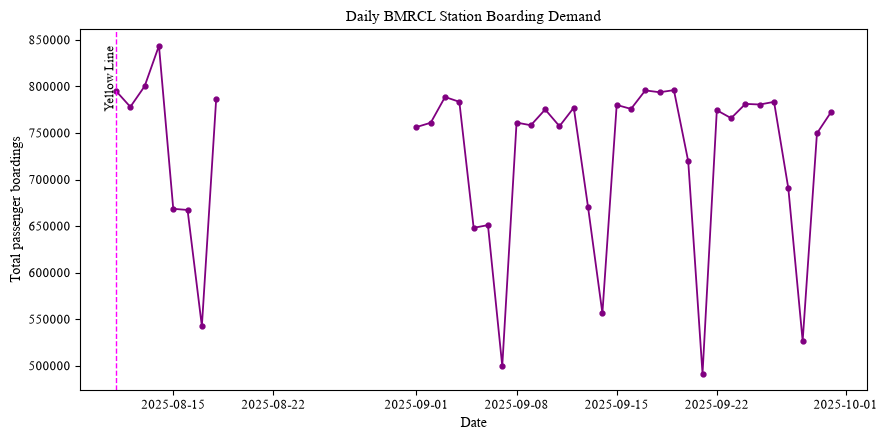

Saved: figures\fig1_daily_boarding_demand.png


In [24]:
# Figure 1: daily network boarding demand.
# Reindex across the calendar so the Aug 19–31 data gap is shown as a true gap
# rather than a misleading line segment between Aug 18 and Sep 1.

study_raw = study.copy()
study_raw["demand"] = study_raw["Ridership"]

daily_total = (
    study_raw.groupby("Date")["demand"]
    .sum()
    .reindex(
        pd.date_range(
            START_DATE.normalize(),
            END_DATE.normalize(),
            freq="D"
        )
    )
)

fig = plt.figure(figsize=(9, 4.5))

plt.plot(
    daily_total.index,
    daily_total.values,
    color="purple",
    marker="o",
    markersize=3.5,
    linewidth=1.3
)

# Yellow Line operational start
plt.axvline(
    pd.Timestamp("2025-08-11"),
    color="magenta",
    linestyle="--",
    linewidth=1.0
)

# Label
plt.text(
    pd.Timestamp("2025-08-11"),
    daily_total.max(),
    "Yellow Line",
    rotation=90,
    va="top",
    ha="right",
    fontsize=9
)

plt.title("Daily BMRCL Station Boarding Demand")
plt.xlabel("Date")
plt.ylabel("Total passenger boardings")

save_show(
    fig,
    "fig1_daily_boarding_demand.png"
)

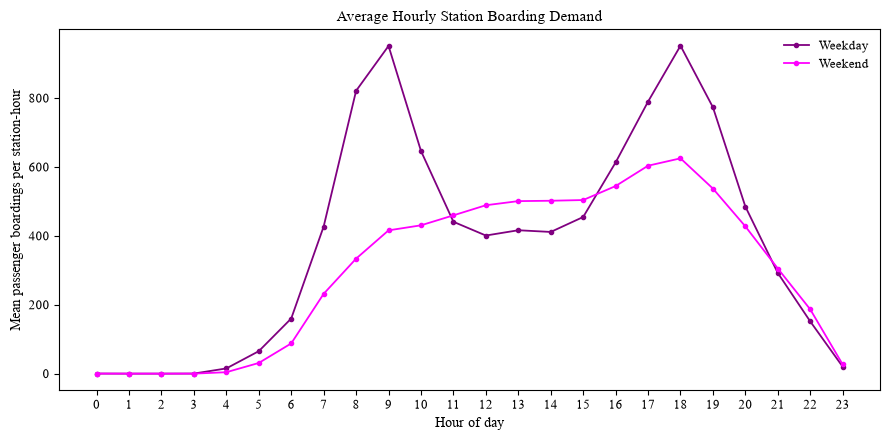

Saved: figures\fig2_hourly_profile_weekday_weekend.png


In [26]:
# Figure 2: average hourly profile, weekday vs weekend.

tmp = study_raw.copy()

tmp["day_type"] = np.where(
    tmp["datetime"].dt.dayofweek < 5,
    "Weekday",
    "Weekend"
)

hour_profile = (
    tmp.groupby(["day_type", "Hour"])["demand"]
    .mean()
    .reset_index()
)

fig = plt.figure(figsize=(9, 4.5))

colors = {
    "Weekday": "purple",
    "Weekend": "magenta"
}

for label in ["Weekday", "Weekend"]:

    d = hour_profile[
        hour_profile["day_type"] == label
    ]

    plt.plot(
        d["Hour"],
        d["demand"],
        color=colors[label],
        marker="o",
        markersize=3,
        linewidth=1.3,
        label=label
    )

plt.title("Average Hourly Station Boarding Demand")

plt.xlabel("Hour of day")

plt.ylabel(
    "Mean passenger boardings per station-hour"
)

plt.xticks(range(24))

plt.legend(
    loc="upper right",
    frameon=False
)

save_show(
    fig,
    "fig2_hourly_profile_weekday_weekend.png"
)

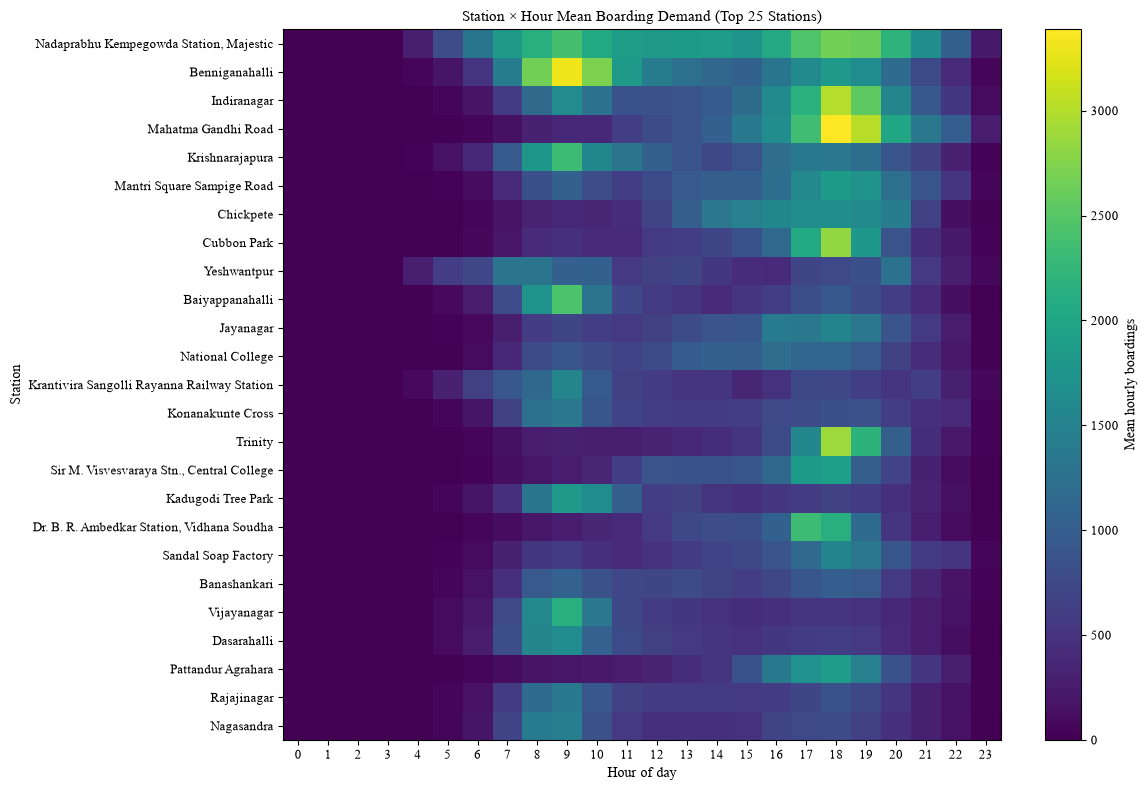

Saved: figures\fig3_station_hour_heatmap_top25.png


In [27]:

# Figure 3: station x hour mean demand heatmap, sorted by mean demand.
station_hour_matrix = (
    study_raw.groupby(["Station", "Hour"])["demand"]
    .mean()
    .unstack(fill_value=np.nan)
)

station_order = (
    station_hour_matrix.mean(axis=1)
    .sort_values(ascending=False)
    .index
)

top_n = 25
heat = station_hour_matrix.loc[station_order[:top_n]]

fig = plt.figure(figsize=(12, 8))
plt.imshow(heat.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="Mean hourly boardings")
plt.title(f"Station × Hour Mean Boarding Demand (Top {top_n} Stations)")
plt.xlabel("Hour of day")
plt.ylabel("Station")
plt.xticks(range(24), range(24))
plt.yticks(range(top_n), heat.index)
save_show(fig, "fig3_station_hour_heatmap_top25.png")


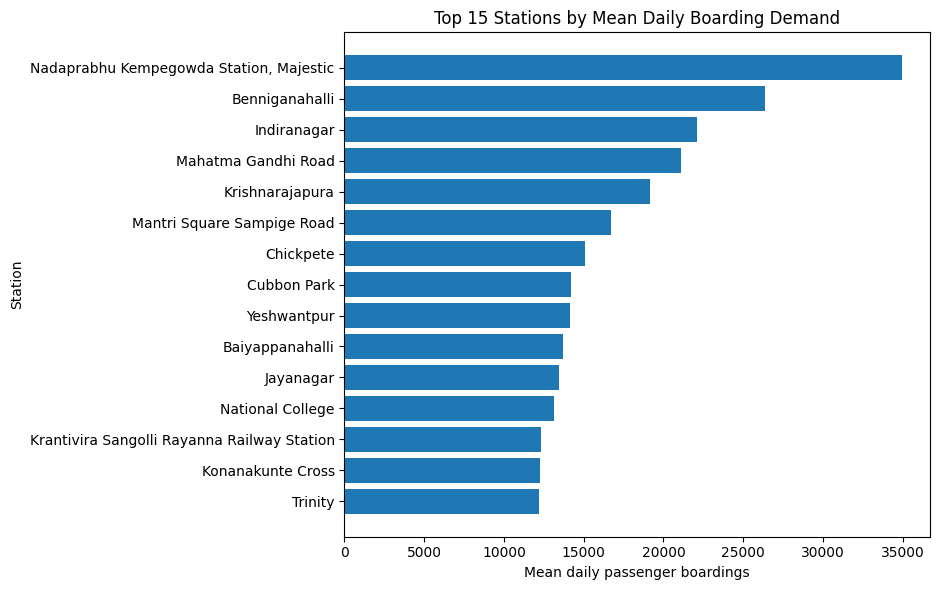

Saved: figures/fig4_top15_station_daily_boardings.png


In [22]:

# Figure 4: station ranking by mean daily boardings.
station_daily = (
    study_raw.groupby(["Date", "Station"])["demand"]
    .sum()
    .reset_index()
)

station_mean_daily = (
    station_daily.groupby("Station")["demand"]
    .mean()
    .sort_values(ascending=True)
)

top15 = station_mean_daily.tail(15)

fig = plt.figure(figsize=(9.5, 6))
plt.barh(top15.index, top15.values)
plt.title("Top 15 Stations by Mean Daily Boarding Demand")
plt.xlabel("Mean daily passenger boardings")
plt.ylabel("Station")
save_show(fig, "fig4_top15_station_daily_boardings.png")


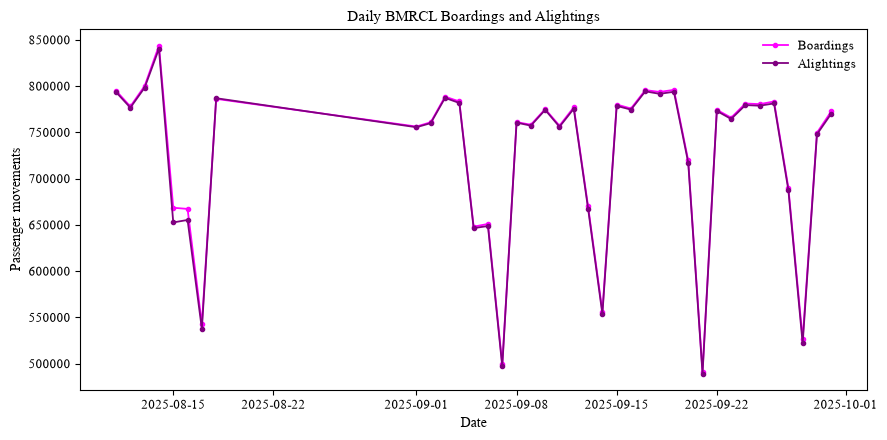

Saved: figures\fig5_daily_boardings_vs_alightings.png


In [30]:
fig = plt.figure(figsize=(9, 4.5))

plt.plot(
    entry_exit_daily.index,
    entry_exit_daily["boardings"],
    color="magenta",
    marker="o",
    markersize=3,
    linewidth=1.3,
    label="Boardings"
)

plt.plot(
    entry_exit_daily.index,
    entry_exit_daily["alightings"],
    color="purple",
    marker="o",
    markersize=3,
    linewidth=1.3,
    label="Alightings"
)

plt.title("Daily BMRCL Boardings and Alightings")
plt.xlabel("Date")
plt.ylabel("Passenger movements")

plt.legend(
    loc="upper right",
    frameon=False
)

save_show(fig, "fig5_daily_boardings_vs_alightings.png")

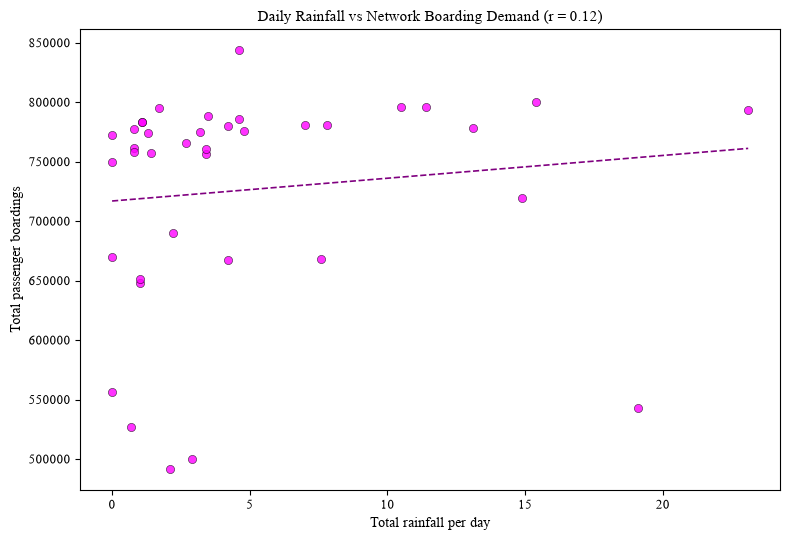

Saved: figures\fig6_rainfall_vs_daily_demand.png


In [32]:
# Figure 6: Daily rainfall vs network boarding demand

# ---------------------------------------------------------
# 1. Prepare daily BMRCL boarding demand
# ---------------------------------------------------------

daily_boardings = (
    study_raw
    .groupby("Date")["demand"]
    .sum()
    .rename("daily_boardings")
)


# ---------------------------------------------------------
# 2. Prepare daily rainfall
# ---------------------------------------------------------

# Restrict weather to the study period
weather_study = weather[
    weather["datetime"].between(
        START_DATE,
        END_DATE + pd.Timedelta(hours=23)
    )
].copy()

# Aggregate hourly rainfall into daily rainfall
daily_rainfall = (
    weather_study
    .assign(Date=weather_study["datetime"].dt.normalize())
    .groupby("Date")["prcp"]
    .sum()
    .rename("daily_rainfall")
)


# ---------------------------------------------------------
# 3. Combine rainfall and demand
# ---------------------------------------------------------

rain_demand = pd.concat(
    [
        daily_boardings,
        daily_rainfall
    ],
    axis=1
).dropna()


# ---------------------------------------------------------
# 4. Calculate correlation
# ---------------------------------------------------------

corr = rain_demand["daily_rainfall"].corr(
    rain_demand["daily_boardings"]
)


# ---------------------------------------------------------
# 5. Plot
# ---------------------------------------------------------

fig = plt.figure(figsize=(8, 5.5))

plt.scatter(
    rain_demand["daily_rainfall"],
    rain_demand["daily_boardings"],
    color="magenta",
    edgecolor="black",
    linewidth=0.4,
    alpha=0.8,
    s=35
)


# ---------------------------------------------------------
# 6. Add linear trend line
# ---------------------------------------------------------

if (
    len(rain_demand) >= 2
    and rain_demand["daily_rainfall"].nunique() > 1
):

    x = rain_demand["daily_rainfall"].values
    y = rain_demand["daily_boardings"].values

    slope, intercept = np.polyfit(x, y, 1)

    xx = np.linspace(
        x.min(),
        x.max(),
        100
    )

    plt.plot(
        xx,
        slope * xx + intercept,
        color="purple",
        linestyle="--",
        linewidth=1.2
    )


# ---------------------------------------------------------
# 7. Formatting
# ---------------------------------------------------------

plt.title(
    f"Daily Rainfall vs Network Boarding Demand (r = {corr:.2f})"
)

plt.xlabel(
    "Total rainfall per day"
)

plt.ylabel(
    "Total passenger boardings"
)

save_show(
    fig,
    "fig6_rainfall_vs_daily_demand.png"
)

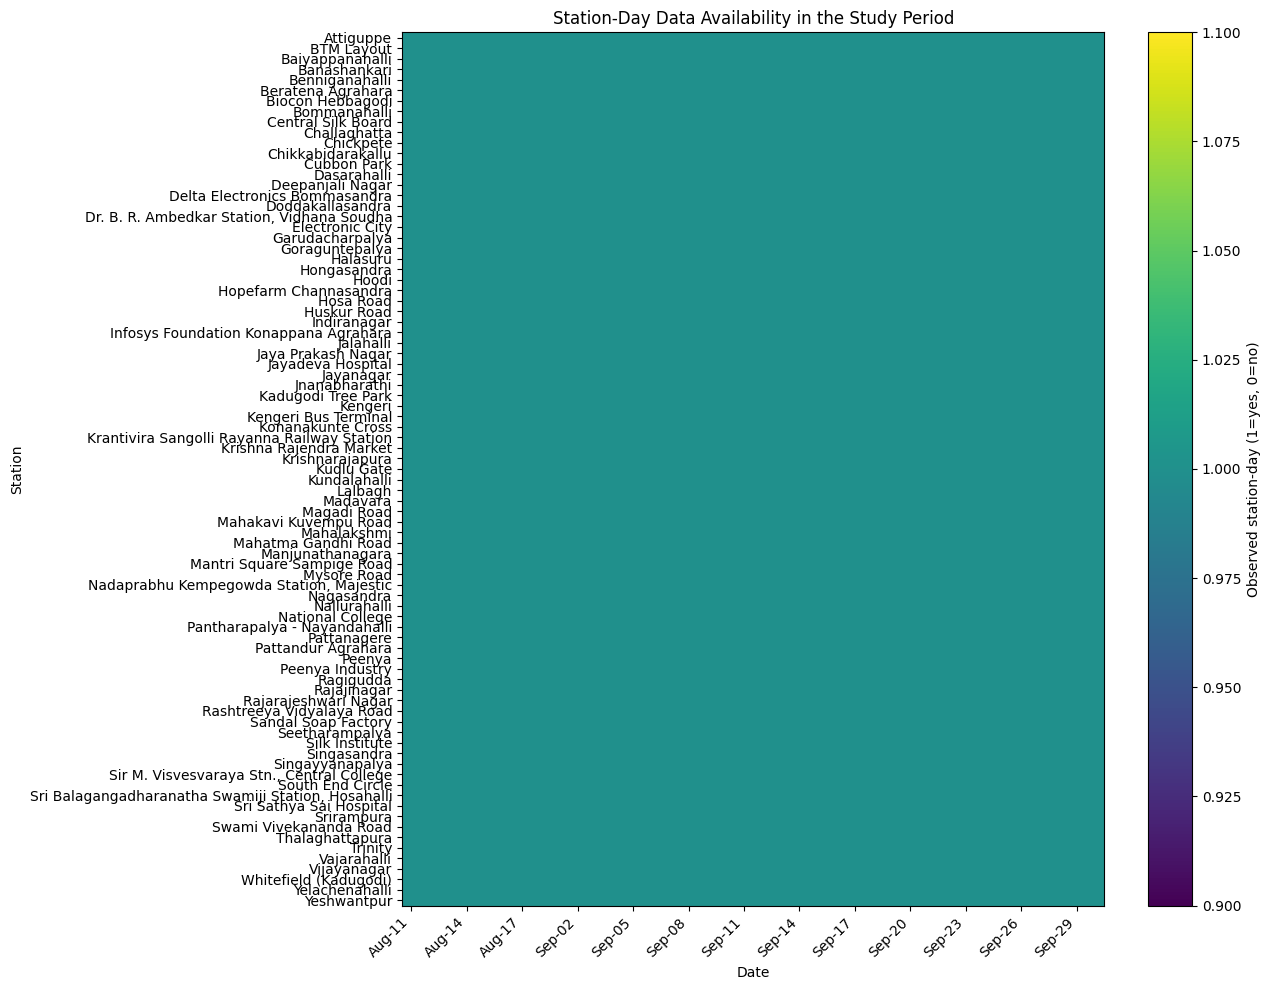

Saved: figures/fig7_station_day_availability.png


In [25]:

# Figure 7: station-day availability heatmap.
availability = (
    study_raw.assign(observed=1)
    .drop_duplicates(["Date", "Station"])
    .pivot(index="Station", columns="Date", values="observed")
    .reindex(index=sorted(study_raw["Station"].unique()))
    .fillna(0)
)

fig = plt.figure(figsize=(13, 10))
plt.imshow(availability.values, aspect="auto", interpolation="nearest")
plt.colorbar(label="Observed station-day (1=yes, 0=no)")
plt.title("Station-Day Data Availability in the Study Period")
plt.xlabel("Date")
plt.ylabel("Station")

date_labels = [d.strftime("%b-%d") for d in availability.columns]
step = max(1, len(date_labels) // 12)
plt.xticks(
    range(0, len(date_labels), step),
    [date_labels[i] for i in range(0, len(date_labels), step)],
    rotation=45,
    ha="right"
)
plt.yticks(range(len(availability.index)), availability.index)
save_show(fig, "fig7_station_day_availability.png")


## 10. Compact validation report

In [26]:

validation_report = pd.DataFrame([
    ("Primary demand rows", len(station_hourly), "Information"),
    ("Primary demand stations", station_hourly["Station"].nunique(), "Information"),
    ("Primary demand observed dates", station_hourly["Date"].nunique(), "Information"),
    ("Primary duplicate station-hours", station_hourly.duplicated(["Date","Hour","Station"]).sum(), "Should be 0"),
    ("Primary negative ridership rows", int((station_hourly["Ridership"] < 0).sum()), "Should be 0"),
    ("Exit duplicate station-hours", station_exits.duplicated(["Date","Hour","Station"]).sum(), "Should be 0"),
    ("Weather duplicate timestamps", weather.duplicated(["datetime"]).sum(), "Should be 0"),
    ("Calendar duplicate dates", calendar["date"].duplicated().sum(), "Should be 0"),
    ("OD duplicate keys", stationpair.duplicated(od_key).sum(), "Should be 0"),
    ("OD Revenue formula mismatches", int((stationpair["Revenue"] != stationpair["Ridership"] * stationpair["Fare"]).sum()), "Should be 0"),
    ("September wide/canonical row mismatches", int((sept_compare["_merge"] != "both").sum()), "Should be 0"),
    ("September wide/canonical ridership mismatches", int((both["Ridership"] != both["ridership_wide"]).sum()), "Should be 0"),
    ("Master duplicate station-datetime rows", master.duplicated(["Station","datetime"]).sum(), "Should be 0"),
], columns=["Check", "Value", "Expectation"])

display(validation_report)
validation_report.to_csv(OUTPUT_DIR / "validation_report.csv", index=False)

print("\nKey modeling notes:")
print("1. Use station-hourly.csv as the canonical boarding-demand target source.")
print("2. Start the primary experiment on Aug 11, 2025.")
print("3. Keep the Aug 19–31 gap as a gap; do not impute zeros.")
print("4. Build lags from exact timestamps, not blind row shifts.")
print("5. Use weather at time t, not observed weather at t+1.")
print("6. Keep OD data for a later spatial experiment; exclude Fare/Revenue from predictive inputs.")


,Check,Value,Expectation
0,Primary demand rows,92280,Information
1,Primary demand stations,83,Information
2,Primary demand observed dates,48,Information
3,Primary duplicate station-hours,0,Should be 0
4,Primary negative ridership rows,0,Should be 0
5,Exit duplicate station-hours,0,Should be 0
6,Weather duplicate timestamps,0,Should be 0
7,Calendar duplicate dates,0,Should be 0
8,OD duplicate keys,0,Should be 0
9,OD Revenue formula mismatches,0,Should be 0



Key modeling notes:
1. Use station-hourly.csv as the canonical boarding-demand target source.
2. Start the primary experiment on Aug 11, 2025.
3. Keep the Aug 19–31 gap as a gap; do not impute zeros.
4. Build lags from exact timestamps, not blind row shifts.
5. Use weather at time t, not observed weather at t+1.
6. Keep OD data for a later spatial experiment; exclude Fare/Revenue from predictive inputs.



## 11. Outputs

After running the notebook, the following are created:

### Processed data
- `processed/bmrcl_master_next_hour_validation.csv`
- `processed/bmrcl_training_ready_next_hour.csv`

### Validation
- `outputs/validation_report.csv`

### Paper figures
- `fig1_daily_boarding_demand.png`
- `fig2_hourly_profile_weekday_weekend.png`
- `fig3_station_hour_heatmap_top25.png`
- `fig4_top15_station_daily_boardings.png`
- `fig5_daily_boardings_vs_alightings.png`
- `fig6_rainfall_vs_daily_demand.png`
- `fig7_station_day_availability.png`

These figures are intended as starting points for the paper. Before publication, captions, font sizing, and any station labels can be adapted to the IEEE two-column layout.
